In [6]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)
     

Running on: cpu


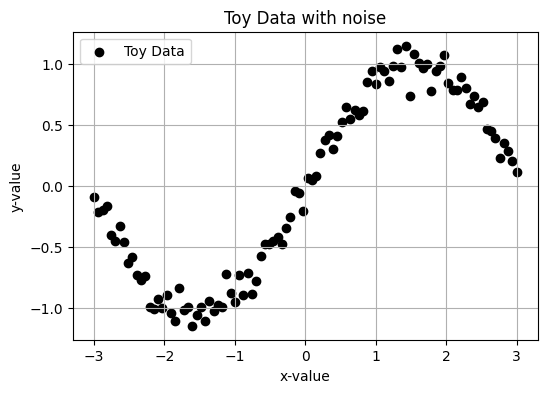

Initial w: -0.14153707420504144
Initial b: -0.04206453227653591


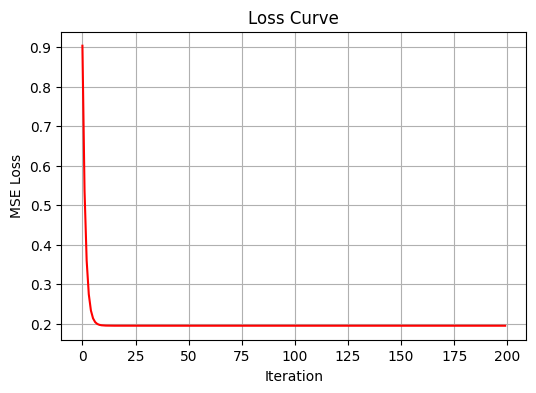

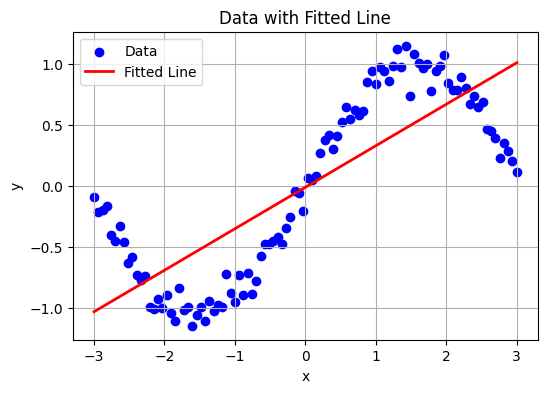

In [9]:
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

#ploting the data 
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='black', label='Toy Data')
plt.title("Toy Data with noise")
plt.xlabel("x-value")
plt.ylabel("y-value")
plt.legend()
plt.grid(True)
plt.show()


#Initialise w and b to small random values.
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

print("Initial w:", w)
print("Initial b:", b)

lr = 0.05
num_steps = 200
loss_history = []

for step in range(num_steps):

    # Forward pass
    y_hat = w * x + b

    # Compute loss
    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)

    # Compute gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    #Update parameters
    w = w - lr * dw
    b = b - lr * db

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# (a) Loss curve
plt.figure(figsize=(6, 4))
plt.plot(loss_history, color='red')
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# (b) Data with fitted line
y_hat = w * x + b

plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, y_hat, color='red', linewidth=2, label='Fitted Line')
plt.title("Data with Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()





![Derivative](der.png) 
```python
dw = np.mean(2 * (y_hat - y) * x)
```

because `np.mean(...)` computes the average, which is equivalent ecause `np.mean(...)` computes the average, which is equivalent to

$$
\frac{1}{n}\sum.
$$



The model is underfitting.

A single neuron can only learn a linear relationship since its formula for pridicition is a straight line 

however the target function which is 
$$
\hat{y}=wx+b,
$$

which represents a straight line. However, the target function

$$
y=\sin(x)
$$

is non-linear and continuouslt curves up and down.No mattere how trained a model is , adjusting the weight (w) and bias (b) only changes the slope and the position of the line.it cannot produce the curved shape of a sine wave.

Initially, the loss decreases as the model identifies the best possible straight-line relationship. However, after a certain point, the loss stops improving because the model has reached the limits of its capacity. This demonstrates **underfitting**, where the model is too simple to effectively capture the true pattern present in the data.


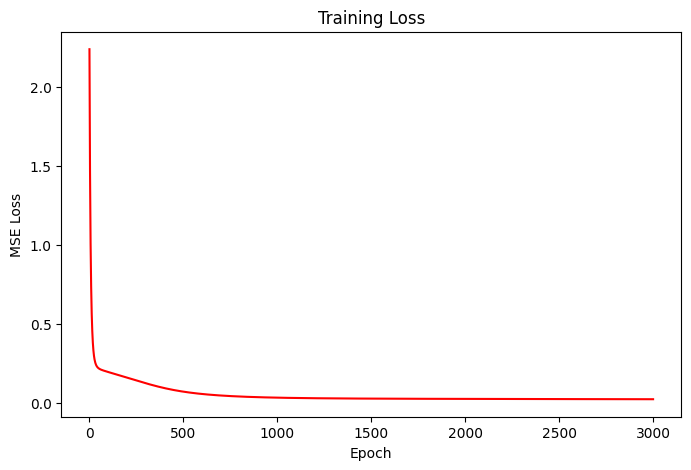

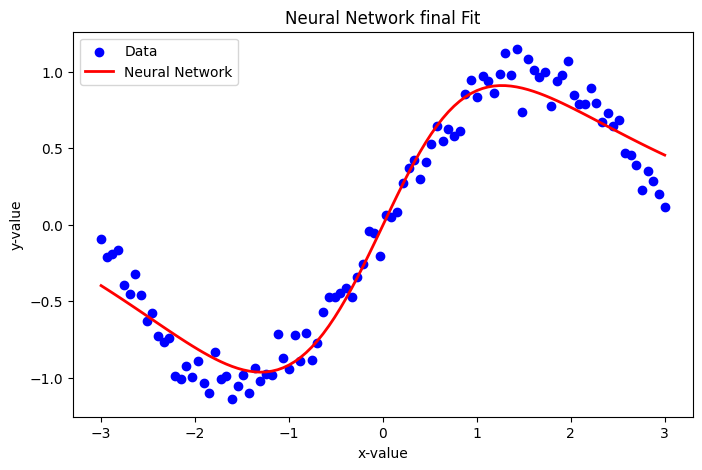

In [ ]:

# Make x and y column vectors
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ W1 + b1 
h  = np.tanh(z1) 
y_hat = h @ W2 + b2 
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
lr = 0.01
epochs = 3000

loss_history = []

for epoch in range(epochs):
  z1 = x @ W1 + b1
  h = np.tanh(z1)
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat - y) ** 2)
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis=0)

  # Update
  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2
  loss_history.append(loss)

  # TODO: Plot the loss curve AND the final fit over the data.

plt.figure(figsize=(8,5))
plt.plot(loss_history, color="red")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data", color="blue")
plt.plot(x, y_hat, color="red", linewidth=2, label="Neural Network")
plt.title("Neural Network final Fit")
plt.xlabel("x-value")
plt.ylabel("y-value")
plt.legend()
plt.show()

Without the tanh activation function, every layer only performs a linear operation. Combining several linear layers still gives a linear model, so the network behaves like a single neuron. As a result, it can only learn a straight-line relationship and cannot fit the curved shape of the sine function.

The hidden layer computes
$$
h = xW_1 + b_1,
$$

and the output layer computes

$$
\hat{y} = hW_2 + b_2.
$$

Substituting the first equation into the second gives

$$
\hat{y} = (xW_1 + b_1)W_2 + b_2.
$$

Expanding,

$$
\hat{y} = x(W_1W_2) + (b_1W_2 + b_2).
$$

Let

$$
W = W_1W_2
\quad \text{and} \quad
b = b_1W_2 + b_2.
$$

Then the equation becomes

$$
\boxed{\hat{y} = xW + b}
$$

Q2.
he 8 hidden neurons each learned a different feature of the sine wave. Using the tanh activation function, they produced different non-linear outputs, which the output neuron combined to create a curve that closely matched the target function.

Q3.
Backpropagation is the process the network uses to learn. It calculates the prediction error, determines how much each weight contributed to that error, and updates the weights to improve the model's accuracy over time.
